1. Import the data and group the rows by star. np.loadtxt / np.genfromtxt / astropy.ascii.read — LEC2; check out CODING/ examples


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Gaia_Dataset = "gaia_m31_lcs.csv"

dt = [("source_id", "i8"), ("t_year", "f8"), ("gmag", "f8"), ("gmag_err", 'f8')]

df = np.genfromtxt(Gaia_Dataset, delimiter=',', names=True, dtype=dt)

df = df[np.lexsort((df["t_year"], df["source_id"]))]

ids, start, n = np.unique(df["source_id"], return_index=True, return_counts=True)
stars = {sid: df[s:s+k] for sid, s, k in zip(ids, start, n)}

# Sanity checks to make sure the file is correct
print(f"rows: {len(df):,}   (expect 92,590)")
print(f"stars: {len(ids):,}   (expect 2,025)")
print(f"epochs per star: min {n.min()}, median {int(np.median(n))}, max {n.max()}   (expect min >= 30)")
print(f"time range: {df['t_year'].min():.3f} - {df['t_year'].max():.3f}   (expect 2014.6 - 2017.4)")
print(f"G range: {df['gmag'].min():.2f} - {df['gmag'].max():.2f}   (expect < 17)")
print(f"median gmag_err: {1e3*np.median(df['gmag_err']):.2f} mmag")
print(f"NaNs: {sum(np.isnan(df[c]).sum() for c in ('t_year', 'gmag', 'gmag_err'))}")
print(f"non-positive errors: {(df['gmag_err'] <= 0).sum()}")


rows: 92,590   (expect 92,590)
stars: 2,025   (expect 2,025)
epochs per star: min 30, median 41, max 99   (expect min >= 30)
time range: 2014.645 - 2017.404   (expect 2014.6 - 2017.4)
G range: 8.26 - 17.30   (expect < 17)
median gmag_err: 2.27 mmag
NaNs: 0
non-positive errors: 0


2. Pick three stars and plot their light curves clearly; think about presentation.
Check residuals for any abnormalities

{'Average Star': 369118427247497728, 'Strongest Trend': 382186599682713984, 'Brightest Star': 381669249398576896}


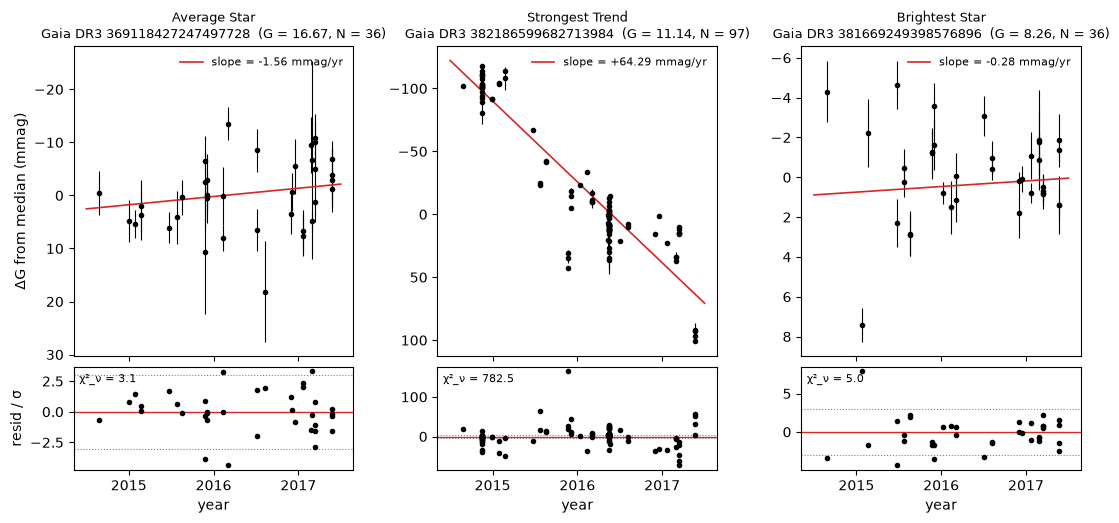

In [20]:
"""GU4303 Lab 1 -- Task 2: three light curves with fits and residual panels.
Run task1_load.py first (it writes gaia_grouped.npz)."""


z = np.load("gaia_grouped.npz")
df, ids, start, n, g_med = z["df"], z["ids"], z["start"], z["n"], z["g_med"]
T0 = 2016.0                                   # centre the time axis

def star(i):
    s = df[start[i]:start[i] + n[i]]
    return s["t_year"], s["gmag"], s["gmag_err"]

# --- Quick per-star diagnostics, only used to choose the three stars ---
chi2_const, slope_z = np.empty(len(ids)), np.empty(len(ids))
for i in range(len(ids)):
    t, m, e = star(i)
    w = 1 / e**2
    mbar = np.sum(w * m) / np.sum(w)
    chi2_const[i] = np.sum(w * (m - mbar)**2) / (n[i] - 1)       # reduced chi2 of a flat line
    p, C = np.polyfit(t - T0, m, 1, w=1 / e, cov="unscaled")
    slope_z[i] = p[0] / np.sqrt(C[0, 0])

picks = {
    "Average Star": np.argsort(chi2_const)[len(ids) // 2],        # median flat-line chi2
    "Strongest Trend": np.argmax(np.abs(slope_z)),
    "Brightest Star": np.argmin(g_med),                           # where an error floor bites hardest
}

# --- Figure: 3 columns, light curve on top, normalized residuals below ---
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.3})
tt = np.linspace(2014.5, 2017.5, 200)

for col, (label, i) in enumerate(picks.items()):
    t, m, e = star(i)
    ref = np.median(m)
    dm = 1e3 * (m - ref)                      # plot in mmag relative to median
    p = np.polyfit(t - T0, m, 1, w=1 / e)
    resid = (m - np.polyval(p, t - T0)) / e   # residuals in units of the quoted error
    chi2r = np.sum(resid**2) / (len(t) - 2)

    top, bot = axes[0, col], axes[1, col]
    top.errorbar(t, dm, yerr=1e3 * e, fmt="o", color="k", ms=3, elinewidth=0.8, capsize=0)
    top.plot(tt, 1e3 * (np.polyval(p, tt - T0) - ref), color="C3", lw=1.2,
             label=f"slope = {1e3*p[0]:+.2f} mmag/yr")
    top.invert_yaxis()                        # brighter = up
    top.set_title(f"{label}\nGaia DR3 {ids[i]}  (G = {ref:.2f}, N = {len(t)})", fontsize=9)
    top.set_ylabel("ΔG from median (mmag)" if col == 0 else "")
    top.legend(fontsize=8, loc="best", frameon=False)

    bot.axhline(0, color="C3", lw=1)
    for k in (-3, 3):
        bot.axhline(k, color="grey", ls=":", lw=0.8)
    bot.plot(t, resid, "o", color="k", ms=3)
    bot.set_ylabel("resid / σ" if col == 0 else "")
    bot.set_xlabel("year")
    bot.text(0.02, 0.85, f"χ²_ν = {chi2r:.1f}", transform=bot.transAxes, fontsize=8)

fig.savefig("task2_lightcurves.pdf", bbox_inches="tight")
print({k: int(ids[i]) for k, i in picks.items()})